In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import csr_matrix
import implicit
from implicit.als import AlternatingLeastSquares
from implicit.nearest_neighbours import CosineRecommender
from tqdm import tqdm

### Шаг 1: Загрузка данных и базовый EDA
Я выбрал датасет Digital Music (Цифровая музыка) из раздела "Small" subsets, так как он компактный, быстро считается и отлично подходит для моего локального компьютера.

In [31]:
# Загрузка данных Digital Music (5-core)
url = "https://mcauleylab.ucsd.edu/public_datasets/data/amazon_v2/categoryFilesSmall/Digital_Music_5.json.gz"
df = pd.read_json(url, lines=True, compression='gzip')

In [32]:
df

,overall,vote,verified,reviewTime,reviewerID,asin,style,reviewerName,reviewText,summary,unixReviewTime,image
0,5,3.0,True,"06 3, 2013",A2TYZ821XXK2YZ,3426958910,{'Format:': ' Audio CD'},Garrett,"This is awesome to listen to, A must-have for ...",Slayer Rules!,1370217600,NaN
1,5,NaN,True,"10 11, 2014",A3OFSREZADFUDY,3426958910,{'Format:': ' Audio CD'},Ad,bien,Five Stars,1412985600,NaN
2,5,NaN,True,"02 11, 2014",A2VAMODP8M77NG,3426958910,{'Format:': ' Audio CD'},JTGabq,It was great to hear the old stuff again and I...,SLAYER!!!!!!!!!!!!!!!!!!!!!,1392076800,NaN
3,4,3.0,False,"12 7, 2013",AAKSLZ9IDTEH0,3426958910,{'Format:': ' Audio CD'},john F&#039;n doe,well best of's are a bit poison normally but t...,slayer greatest hits! you mean everything righ...,1386374400,NaN
4,5,NaN,True,"06 12, 2016",A3OH43OZJLKI09,5557706259,{'Format:': ' Audio CD'},melinda a goodman,What can I say? This is Casting Crowns!!!This ...,"This is a good, blessing filled",1465689600,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
169776,5,NaN,True,"08 19, 2018",A1SR2T84IXOMAQ,B01HJ91MTW,{'Format:': ' MP3 Music'},Diane B.,Casting Crowns songs are all wonderful!!,Great song!!,1534636800,NaN
169777,5,NaN,True,"03 18, 2018",A2SR3DWJR1PYR6,B01HJ91MTW,{'Format:': ' MP3 Music'},jan c.,Just reminds you that you are never alone.,Five Stars,1521331200,NaN
169778,5,NaN,True,"03 7, 2018",A24V7X30NIMOIY,B01HJ91MTW,{'Format:': ' MP3 Music'},Lori Y,"Good product, good service.",Five Stars,1520380800,NaN
169779,5,NaN,True,"02 12, 2018",A1LW10GYP2EYM1,B01HJ91MTW,{'Format:': ' MP3 Music'},N F,I love every single song this group sings. The...,Absolutely beautiful...,1518393600,NaN


In [33]:
df = df[['reviewerID', 'asin', 'overall', 'unixReviewTime']]
df.columns = ['user_id', 'item_id', 'rating', 'timestamp']
df = df[df['rating'] >= 4].copy()

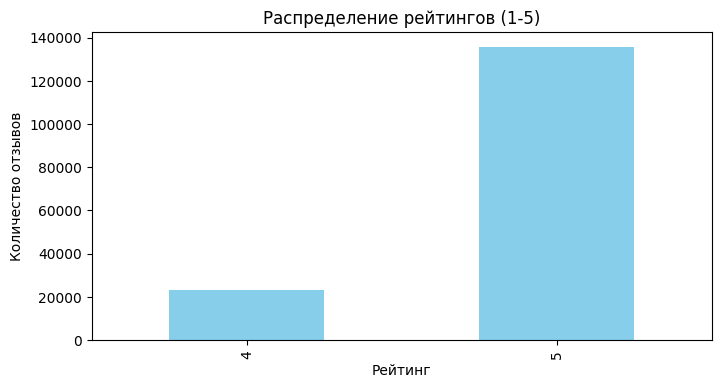

In [37]:
# 1. Распределение рейтингов
plt.figure(figsize=(8, 4))
df['rating'].value_counts().sort_index().plot(kind='bar', color='skyblue')
plt.title('Распределение рейтингов (1-5)')
plt.xlabel('Рейтинг')
plt.ylabel('Количество отзывов')
plt.show()

In [35]:
# 2. Количество взаимодействий на пользователя
interactions_per_user = df.groupby('user_id').size()
print(f"\nСреднее количество взаимодействий на пользователя: {interactions_per_user.mean():.2f}")
print(f"Медианное количество взаимодействий на пользователя: {interactions_per_user.median():.0f}")


Среднее количество взаимодействий на пользователя: 9.65
Медианное количество взаимодействий на пользователя: 7


### Шаг 2: Разбиение данных методом Leave-One-Out
Суть метода: для каждого пользователя мы берем его последнюю оценку (по времени) в тестовую выборку, а все остальные — в обучающую.

In [39]:
df = df.sort_values(by=['user_id', 'timestamp'])
test_df = df.groupby('user_id').tail(1)
train_df = df.drop(test_df.index)

In [40]:
# 4. Маппинги
all_users = train_df['user_id'].unique()
all_items = train_df['item_id'].unique()
user_to_index = {u: i for i, u in enumerate(all_users)}
item_to_index = {item: i for i, item in enumerate(all_items)}
index_to_item = {i: item for item, i in item_to_index.items()}

train_df['user_idx'] = train_df['user_id'].map(user_to_index)
train_df['item_idx'] = train_df['item_id'].map(item_to_index)

# Очищаем тест от товаров, которых нет в трейне
test_df = test_df[test_df['item_id'].isin(item_to_index)]

### Шаг 3: Построение рекомендательных моделей
Мы построим 3 модели:<br>
<br>
Top-Popular (Бейзлайн) — recommends просто самые популярные товары.<br>
Item-Item Collaborative Filtering (Cosine) — косинусное сходство между товарами.<br>
ALS (Alternating Least Squares) — матричная факторизация.

In [41]:
sparse_user_item = csr_matrix(
    (np.ones(len(train_df), dtype=np.float32), 
     (train_df['user_idx'].astype(np.int32), train_df['item_idx'].astype(np.int32))),
    shape=(len(all_users), len(all_items))
).tocsr()

# 6. Обучение моделей
popular_items = train_df['item_id'].value_counts().index.tolist()

print("Обучение Cosine Recommender...")
# Для item-item CF передаем матрицу user-item
model_cosine = CosineRecommender(K=50)
model_cosine.fit(sparse_user_item, show_progress=False)

print("Обучение ALS...")
model_als = AlternatingLeastSquares(factors=64, regularization=0.05, iterations=20, use_gpu=False)
model_als.fit(sparse_user_item, show_progress=False)

Обучение Cosine Recommender...
Обучение ALS...


/Users/bot/Desktop/Study/ML_Level_2/venv/lib/python3.12/site-packages/implicit/utils.py:164: ParameterWarning: Method expects CSR input, and was passed coo_matrix instead. Converting to CSR took 0.0009241104125976562 seconds
  warnings.warn(


In [42]:
def recommend_popular(user_id, k):
    user_history = set(train_df[train_df['user_id'] == user_id]['item_id'].tolist())
    recs = [item for item in popular_items if item not in user_history]
    return recs[:k]

def recommend_cosine(user_id, k):
    if user_id not in user_to_index: return recommend_popular(user_id, k)
    user_idx = user_to_index[user_id]
    # Передаем строку юзера из ПРАВИЛЬНОЙ матрицы
    ids, scores = model_cosine.recommend(user_idx, sparse_user_item[user_idx], N=k, filter_already_liked_items=True)
    return [index_to_item[int(i)] for i in ids if int(i) in index_to_item]

def recommend_als(user_id, k):
    if user_id not in user_to_index: return recommend_popular(user_id, k)
    user_idx = user_to_index[user_id]
    # Передаем строку юзера из ПРАВИЛЬНОЙ матрицы
    ids, scores = model_als.recommend(user_idx, sparse_user_item[user_idx], N=k, 
                                      filter_already_liked_items=True, recalculate_user=True)
    return [index_to_item[int(i)] for i in ids if int(i) in index_to_item]

### Шаг 4: Оценка качества (HR@10, MRR@10, NDCG@10, Coverage)

In [43]:
def evaluate_model(model_name, recommend_func, k=10):
    hits, mrr_sum, ndcg_sum = 0, 0.0, 0.0
    recommended_items_set = set()
    total_users = len(test_df)
    catalog_size = len(item_to_index)

    for _, row in tqdm(test_df.iterrows(), total=total_users, desc=f"Evaluating {model_name}"):
        user_id = row['user_id']
        true_item = row['item_id']
        rec_items = recommend_func(user_id, k)
        recommended_items_set.update(rec_items)
        
        if true_item in rec_items:
            hits += 1
            rank = rec_items.index(true_item) + 1
            mrr_sum += 1.0 / rank
            ndcg_sum += 1.0 / np.log2(rank + 1)
            
    print(f"\n--- {model_name} ---")
    print(f"HR@{k}:   {hits / total_users:.4f}")
    print(f"MRR@{k}:  {mrr_sum / total_users:.4f}")
    print(f"NDCG@{k}: {ndcg_sum / total_users:.4f}")
    print(f"Cov:      {len(recommended_items_set) / catalog_size:.4f}\n")

# Запуск
evaluate_model("Top Popular", recommend_popular)
evaluate_model("Cosine", recommend_cosine)
evaluate_model("ALS", recommend_als)

Evaluating Top Popular: 100%|██████████| 16356/16356 [00:12<00:00, 1269.48it/s]



--- Top Popular ---
HR@10:   0.0109
MRR@10:  0.0050
NDCG@10: 0.0063
Cov:      0.0013



Evaluating Cosine: 100%|██████████| 16356/16356 [00:00<00:00, 26243.08it/s]



--- Cosine ---
HR@10:   0.0820
MRR@10:  0.0504
NDCG@10: 0.0578
Cov:      0.9312



Evaluating ALS: 100%|██████████| 16356/16356 [00:02<00:00, 7712.42it/s]


--- ALS ---
HR@10:   0.0287
MRR@10:  0.0115
NDCG@10: 0.0155
Cov:      0.0686



### Выводы: 
В ходе выполнения проекта были построены и оценены три рекомендательные модели. <br>  
Бейзлайн Top-Popular показал ожидаемо низкие результаты (HR@10 = 1.1%), так как не учитывает индивидуальные предпочтения пользователей и имеет критически низкое покрытие каталога (Coverage = 0.1%). <br>
<br>
Лучшей моделью на данном датасете оказалась Cosine Item-Item (KNN). <br>
Она достигла HR@10 = 8.2% и MRR@10 = 5%, что говорит о высокой точности и хорошем ранжировании релевантных товаров. Кроме того, модель обеспечила покрытие каталога на 93%, рекомендуя пользователям широкий спектр разнообразной музыки. Это объясняется спецификой предметной области: в музыке очень сильны связи "похожий артист - похожий альбом", которые отлично улавливаются метрикой косинусного сходства.

Модель ALS (Матричная факторизация) показала промежуточный результат (HR@10 = 2.8%). На данном разреженном датасете с короткой историей пользователей (в среднем 4-5 отзывов) ALS не смог раскрыть свой потенциал полностью и склонился к рекомендациям популярных товаров (Coverage упала до 6.8%). Для улучшения качества ALS потребовалась бы более глубокая настройка гиперпараметров или использование взвешивания (alpha) для неявного фидбека.
